In [93]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
import numpy as np
from scipy.stats import linregress
from scipy.stats import stats

In [95]:
#reading files 
# combined U-Th Column sediment pteropod data and Me/Ca sediment pteropod data

sedidata = pd.read_excel('UTh and MeCa combined sediment pteropods.xlsx', sheet_name= 'combined sedimentary pteropods',header=1, skiprows=[3, 5, 12]) 
sedidatacsv = "UTh and MeCa combined sediment pteropods.csv"
sedidata.to_csv(sedidatacsv, index=False)
sedidatacsv = pd.read_csv(sedidatacsv)

n = sedidata['number']
print(sedidata.columns)

Index(['Type', 'ID', 'Label', 'Cleaning', 'number', 'Sr/Ca [mmol/mol]',
       'Ba/Ca [umol/mol]', 'U/Ca [nmol/mol]', 'Na_Ca [mmol/mol]',
       'Mg_Ca [mmol/mol]', 'Mn_Ca [umol/mol]', 'Fe_Ca [umol/mol]',
       'Al_Ca [umol/mol]', '230Th/238U A.R.', '± 2 s.e.', '230Th/234U A.R.',
       '± 2 s.e..1', '234U (dpm/g)', '± 2 s.e..2', '238U (dpm/g)',
       '± 2 s.e..3', '[234U] nmols/ mol Ca', '[238U] nmols/ g CaCO3',
       '[234U] nmols/ Ca mol', '[238U]nmols/ Ca mol', '[234U]', '[238U]',
       '[234U]/[238U]', 'Measured U/Ca [nmol/mol]', 'Unnamed: 29'],
      dtype='object')


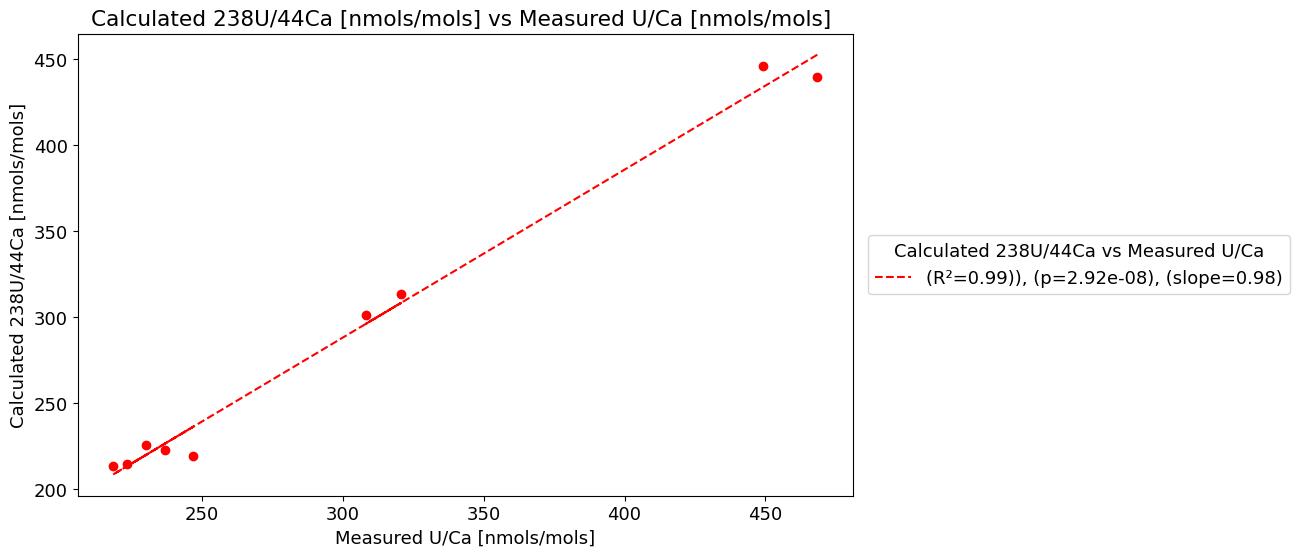

In [97]:
#Graph 1: sedimentary measured U nmols/Ca mols Ratios vs sedimentary columns 238U nmols/44Ca mols calculated

#index data
# measured U nmols/Ca mols from cleaned pteropods (excluding contaminated values)
U_CaMeas = sedidata['U/Ca [nmol/mol]']

#calculated U nmols/Ca mols from column pteropods (excluding contaminated values)
U_CaCalc = sedidata['[238U]nmols/ Ca mol']

# calulate linear regression
slope, intercept, r_value, p_value, std_err = linregress( U_CaMeas, U_CaCalc)
regression_y = slope * U_CaMeas + intercept
r_squared = r_value**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(U_CaMeas, U_CaCalc, color = 'r')

#plot linear regression
plt.plot(U_CaMeas, regression_y, label=f'(R²={r_squared:.2f})), (p={p_value:.2e}), (slope={slope:.2f})', color='r', linestyle='--')

# axis labels 
plt.xlabel('Measured U/Ca [nmols/mols]')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Measured U/Ca [nmols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Calculated 238U/44Ca vs Measured U/Ca', borderaxespad=0)




7    213.455796
8    225.634111
Name: [238U]nmols/ Ca mol, dtype: float64 4    214.394594
5    222.865186
6    219.164513
Name: [238U]nmols/ Ca mol, dtype: float64


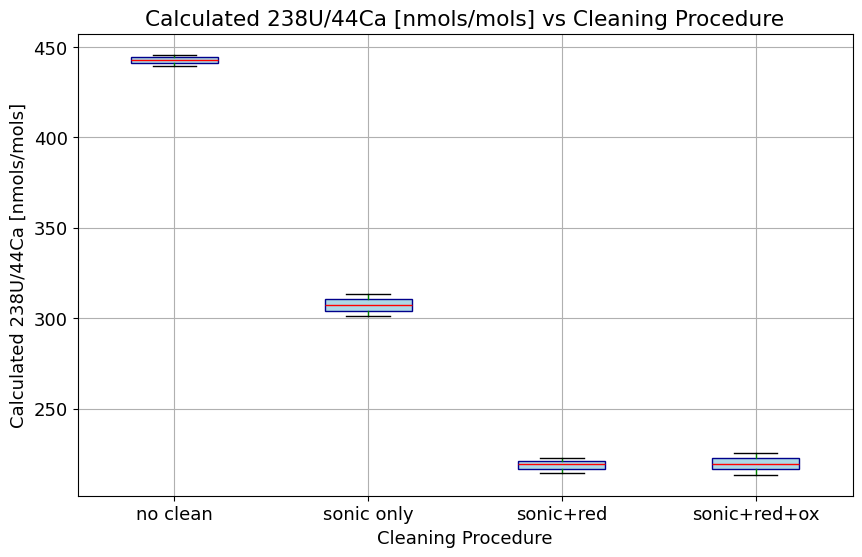

In [99]:
# Graph 2: sedimentary pteropods columns 238U nmols/44Ca mols calculated vs cleaning procedures


#index data by cleaning type
noclean = sedidatacsv[sedidatacsv['Cleaning'].str.contains('no clean')]
sonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic only')]

#regex gets rid of regex operator of "+"
redsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic+red', regex=False)]
oxredsonic = sedidatacsv[sedidatacsv['Cleaning'].str.contains('sonic++red+ox', regex=False)]


# getting U nmols/ Ca mols from each cleaning type 
nocleanU = noclean['[238U]nmols/ Ca mol']
sonicU = sonic['[238U]nmols/ Ca mol']
redsonicU = redsonic['[238U]nmols/ Ca mol']
oxredsonicU = oxredsonic['[238U]nmols/ Ca mol']
print(oxredsonicU, redsonicU)
#combining data
cleantype = nocleanU, sonicU, redsonicU, oxredsonicU
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('Calculated 238U/44Ca [nmols/mols]')

#plot title
plt.title('Calculated 238U/44Ca [nmols/mols] vs Cleaning Procedure')

#add grid lines
plt.grid()

1.138403054186125
1.1427774448758021


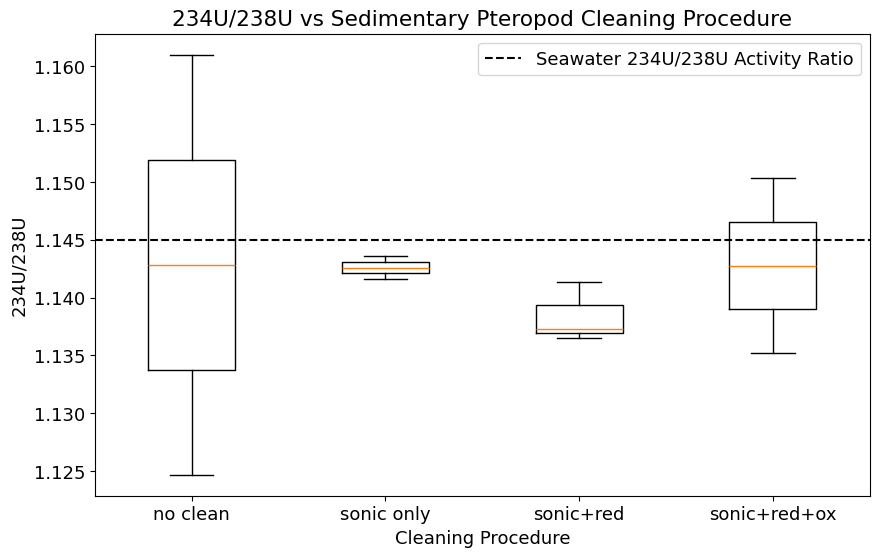

In [101]:
#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

#combining data
cleantype = noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning)



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Sedimentary Pteropod Cleaning Procedure')

print(sum(redsonic234U_238U)/len(redsonic234U_238U))

print(sum(oxredsonic234U_238U)/len(oxredsonic234U_238U))

plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()

0    1
1    1
2    2
3    2
4    3
5    3
6    3
7    4
8    4
Name: number, dtype: int64
1.138403054186125
1.1427774448758021


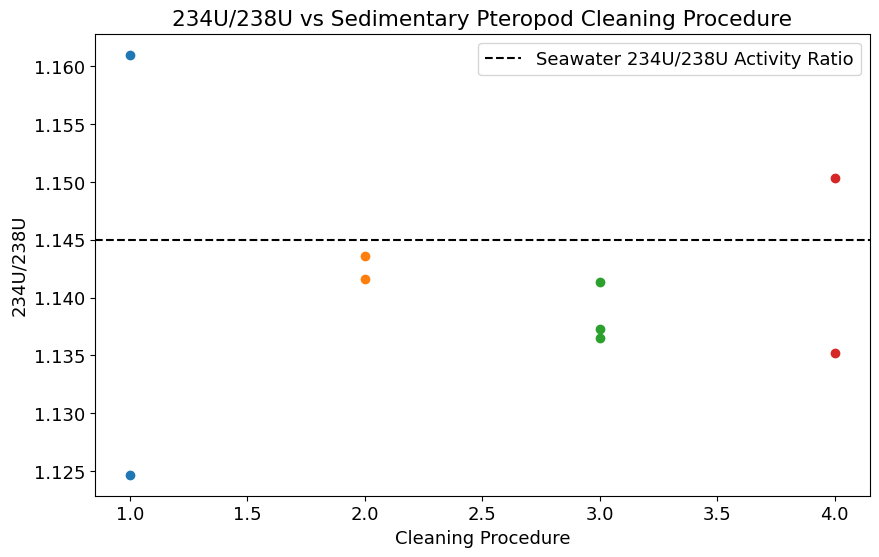

In [103]:
#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure


# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

# 

print(n)
#combining data
cleantype = noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U
cleaning = {
    'no clean' : nocleanU,
    'sonic only': sonicU,
    'sonic+red' : redsonicU,
    'sonic+red+ox' : oxredsonicU
}
#create figure
plt.figure(figsize=(10, 6))

#create boxplot


plt.scatter(n[0:2], noclean234U_238U)
plt.scatter(n[2:4], sonic234U_238U)
plt.scatter(n[4:7], redsonic234U_238U)
plt.scatter(n[7:9], oxredsonic234U_238U)


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Sedimentary Pteropod Cleaning Procedure')

print(sum(redsonic234U_238U)/len(redsonic234U_238U))

print(sum(oxredsonic234U_238U)/len(oxredsonic234U_238U))

plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend()

4    1.137331
5    1.141331
6    1.136548
Name: [234U]/[238U], dtype: float64


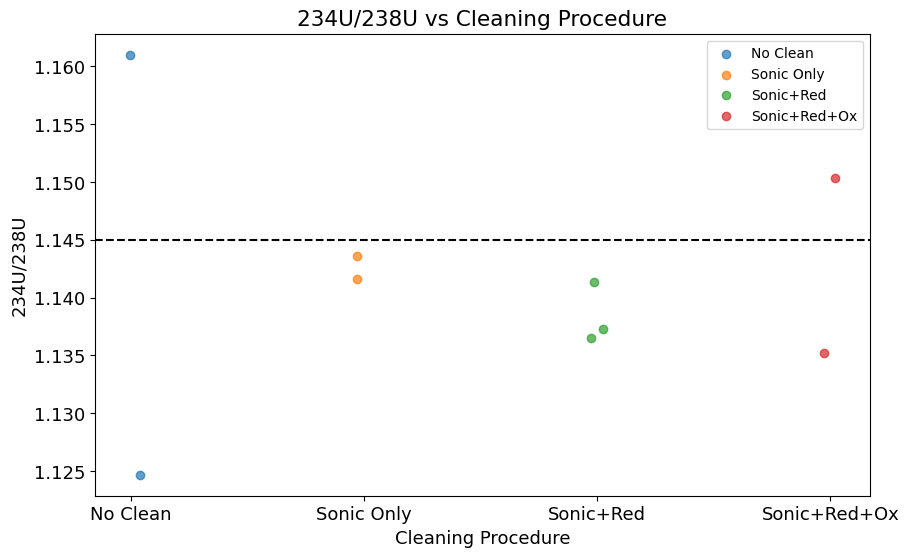

In [105]:
#graph 4 bar plots sedimentary pteropods columns 234U/238U mols vs cleaning procedure

# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']
print(redsonic234U_238U)


#combining data
cleantype = [noclean234U_238U, sonic234U_238U, redsonic234U_238U, oxredsonic234U_238U]
cleaning = ['No Clean','Sonic Only','Sonic+Red','Sonic+Red+Ox']

#create figure
plt.figure(figsize=(10, 6))

#create scatterplot
#enumerate allows for cleantypes to be numbered to be able to scatter plot
for i, values in enumerate(cleantype):
    x = (i+1) + np.random.uniform(-0.04, 0.04, size=len(values)) # so points don’t overlap on x axis 
    plt.scatter(x, values, alpha=0.7)

#replace numbers with category labels
plt.xticks(range(1, len(cleaning)+1), cleaning)


#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U/238U')

#plot title
plt.title('234U/238U vs Cleaning Procedure')
plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')

#plot legend
plt.legend(cleaning, fontsize = 10)

#add grid lines


Text(0.5, 1.0, '234U/238U vs Cleaning Procedure')

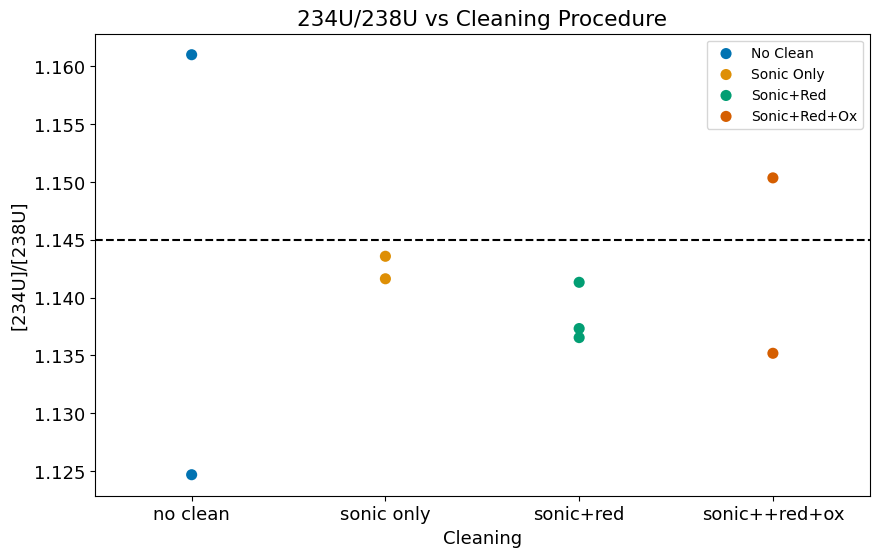

In [107]:
#add error bars 

plt.figure(figsize=(10,6))
sns.stripplot(data=sedidata, x='Cleaning', y='[234U]/[238U]', hue='Cleaning',jitter = False, palette='colorblind', size = 8)
plt.axhline(y=1.145, color='black', linestyle='--', linewidth=1.5, label='Seawater 234U/238U Activity Ratio')
plt.legend(cleaning, fontsize = 10)
plt.title('234U/238U vs Cleaning Procedure')

In [109]:
#ttest for noclean vs sonic
#shift tab= see details 

t_stat_sm, p_val_sm = ttest_ind(noclean234U_238U, sonic234U_238U, alternative='greater', nan_policy='omit')

print(f"One-tailed t-test (noclean > sonic) for 234U/238U: t={t_stat_sm:.4f}, p={p_val_sm:.4f}")


One-tailed t-test (noclean > sonic) for 234U/238U: t=0.0133, p=0.4953


In [111]:
#tttest for noclean vs redsonic

t_stat_sm, p_val_sm = ttest_ind(noclean234U_238U, redsonic234U_238U, alternative='greater', nan_policy='omit')

print(f"One-tailed t-test (noclean > redsonic) for 234U/238U: t={t_stat_sm:.4f}, p={p_val_sm:.4f}")

One-tailed t-test (noclean > redsonic) for 234U/238U: t=0.3253, p=0.3831


In [113]:
#ttest for redsonic vs sonic
t_stat_sm, p_val_sm = ttest_ind(sonic234U_238U, redsonic234U_238U, alternative='greater', nan_policy='omit')

print(f"One-tailed t-test (sonic > redsonic) for 234U/238U: t={t_stat_sm:.4f}, p={p_val_sm:.4f}")

One-tailed t-test (sonic > redsonic) for 234U/238U: t=2.0569, p=0.0659


In [115]:
#t-test for redsonic vs oxredosonic
t_stat_sm, p_val_sm = ttest_ind(redsonic234U_238U, oxredsonic234U_238U, alternative='greater', nan_policy='omit')

print(f"One-tailed t-test (red sonic > oxredsonic) for 234U/238U: t={t_stat_sm:.4f}, p={p_val_sm:.4f}")

One-tailed t-test (red sonic > oxredsonic) for 234U/238U: t=-0.7329, p=0.7416


In [121]:
#two sample t test noclean vs sonic
stats.ttest_ind(a = noclean234U_238U, 
                  b = sonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_22763/1607163069.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = noclean234U_238U,


TtestResult(statistic=0.01330951498696787, pvalue=0.9915180539394429, df=1.00573436615448)

In [123]:
#two sample t test sonic vs redsonic
stats.ttest_ind(a = sonic234U_238U, 
                  b = redsonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_22763/59549715.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = sonic234U_238U,


TtestResult(statistic=2.3737802433420763, pvalue=0.09856854079644231, df=2.986199514658678)

In [127]:
#two sample t test redsonic vs oxredsonic
stats.ttest_ind(a = redsonic234U_238U, 
                  b = oxredsonic234U_238U, equal_var = False )

/var/folders/dl/yffywxpd2fq46h16zbsq2v040000gn/T/ipykernel_22763/3413325303.py:2: DeprecationWarning: Please import `ttest_ind` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.ttest_ind(a = redsonic234U_238U,


TtestResult(statistic=-0.5659542623837838, pvalue=0.6666075315975123, df=1.0769122225885983)

138.403054186125
142.77744487580202
4    137.330571
5    141.330649
6    136.547943
Name: [234U]/[238U], dtype: float64


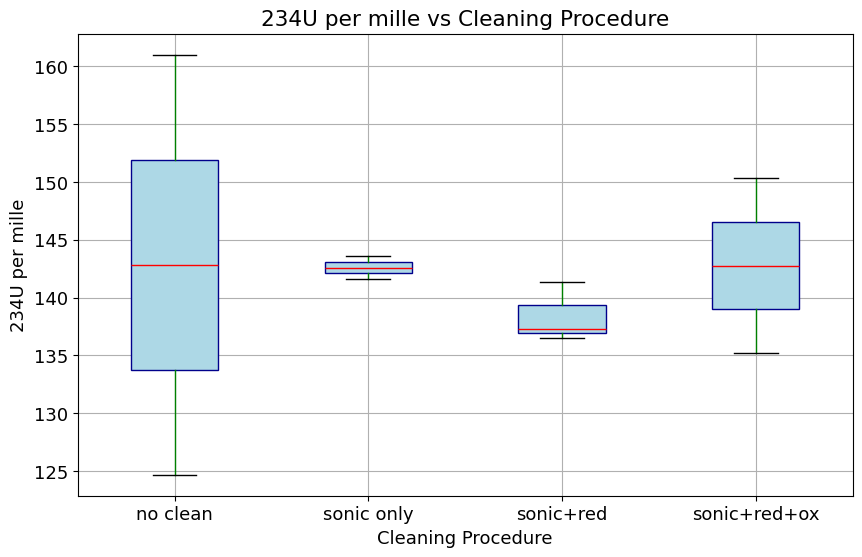

In [75]:
#graph 5: d234U per mille

#graph 3 boxplot sedimentary pteropods columns 234U/238U mols vs cleaning procedure



# getting U nmols/ Ca mols from each cleaning type 
noclean234U_238U = noclean['[234U]/[238U]']
sonic234U_238U = sonic['[234U]/[238U]']
redsonic234U_238U = redsonic['[234U]/[238U]']
oxredsonic234U_238U = oxredsonic['[234U]/[238U]']

noclean234U = (noclean234U_238U - 1)*1000
sonic234U = (sonic234U_238U - 1)*1000
redsonic234U = (redsonic234U_238U - 1)*1000
oxredsonic234U = (oxredsonic234U_238U - 1)*1000

#combining data
cleantype = noclean234U, sonic234U, redsonic234U, oxredsonic234U
cleaning = {'no clean' : nocleanU,'sonic only': sonicU, 'sonic+red' : redsonicU,'sonic+red+ox' : oxredsonicU}

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantype, tick_labels=cleaning, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))



#label axes
plt.xlabel('Cleaning Procedure')
plt.ylabel('234U per mille')

#plot title
plt.title('234U per mille vs Cleaning Procedure')

#add grid lines
plt.grid()

print(sum(redsonic234U)/len(redsonic234U))

print(sum(oxredsonic234U)/len(oxredsonic234U))

print(redsonic234U)


